Practical 3: Data Exploration using Pyspark SQL

In [1]:
#! pip install pyspark pandas matplotlib seaborn

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
spark = SparkSession.builder \
    .appName("Car Price Data Exploration") \
    .getOrCreate()
spark

In [30]:
#df = spark.read.csv("car_price.csv", header=True, inferSchema=True)
df = spark.read.csv("/content/sample_data/car_price.csv", header=True, inferSchema=True)

In [31]:
df.show()

+--------+----+-------------+----------+---------+------------+-----+-----+
|     car|year|Present_Price|Kms_Driven|Fuel_Type|Transmission|Owner|price|
+--------+----+-------------+----------+---------+------------+-----+-----+
|   Swift|2018|          5.6|     27000|   Petrol|      Manual|    0|  4.5|
|    City|2017|          9.8|     32000|   Petrol|      Manual|    0|  7.5|
|   Creta|2019|         13.5|     18000|   Diesel|      Manual|    0| 11.2|
|  Baleno|2020|          7.1|     15000|   Petrol|      Manual|    0|  6.4|
|  Innova|2016|         18.0|     60000|   Diesel|      Manual|    1| 14.5|
|     i20|2019|          7.8|     22000|   Petrol|      Manual|    0|  6.5|
|Fortuner|2018|         32.0|     45000|   Diesel|   Automatic|    0| 28.0|
|   Verna|2017|         10.2|     35000|   Petrol|      Manual|    0|  8.2|
|    Ciaz|2018|          8.7|     28000|   Petrol|      Manual|    0|  7.0|
|    Alto|2020|          3.5|     12000|   Petrol|      Manual|    0|  3.0|
+--------+--

In [8]:
df.printSchema()

root
 |-- car: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- Present_Price: double (nullable = true)
 |-- Kms_Driven: integer (nullable = true)
 |-- Fuel_Type: string (nullable = true)
 |-- Transmission: string (nullable = true)
 |-- Owner: integer (nullable = true)
 |-- price: double (nullable = true)



In [9]:
df.createOrReplaceTempView("car_price")

In [10]:
spark.sql("SELECT car, price FROM car_price ORDER BY price DESC").show()

+--------+-----+
|     car|price|
+--------+-----+
|Fortuner| 28.0|
|  Innova| 14.5|
|   Creta| 11.2|
|   Verna|  8.2|
|    City|  7.5|
|    Ciaz|  7.0|
|     i20|  6.5|
|  Baleno|  6.4|
|   Swift|  4.5|
|    Alto|  3.0|
+--------+-----+



In [11]:
pdf = df.toPandas()
pdf.head()


,car,year,Present_Price,Kms_Driven,Fuel_Type,Transmission,Owner,price
0,Swift,2018,5.6,27000,Petrol,Manual,0,4.5
1,City,2017,9.8,32000,Petrol,Manual,0,7.5
2,Creta,2019,13.5,18000,Diesel,Manual,0,11.2
3,Baleno,2020,7.1,15000,Petrol,Manual,0,6.4
4,Innova,2016,18.0,60000,Diesel,Manual,1,14.5


In [12]:
spark.sql("SELECT * FROM car_price").show()

+--------+----+-------------+----------+---------+------------+-----+-----+
|     car|year|Present_Price|Kms_Driven|Fuel_Type|Transmission|Owner|price|
+--------+----+-------------+----------+---------+------------+-----+-----+
|   Swift|2018|          5.6|     27000|   Petrol|      Manual|    0|  4.5|
|    City|2017|          9.8|     32000|   Petrol|      Manual|    0|  7.5|
|   Creta|2019|         13.5|     18000|   Diesel|      Manual|    0| 11.2|
|  Baleno|2020|          7.1|     15000|   Petrol|      Manual|    0|  6.4|
|  Innova|2016|         18.0|     60000|   Diesel|      Manual|    1| 14.5|
|     i20|2019|          7.8|     22000|   Petrol|      Manual|    0|  6.5|
|Fortuner|2018|         32.0|     45000|   Diesel|   Automatic|    0| 28.0|
|   Verna|2017|         10.2|     35000|   Petrol|      Manual|    0|  8.2|
|    Ciaz|2018|          8.7|     28000|   Petrol|      Manual|    0|  7.0|
|    Alto|2020|          3.5|     12000|   Petrol|      Manual|    0|  3.0|
+--------+--

In [13]:
spark.sql("SELECT COUNT(*) AS total_cars FROM car_price").show()

+----------+
|total_cars|
+----------+
|        10|
+----------+



In [14]:
spark.sql("SELECT DISTINCT Fuel_Type FROM car_price").show()

+---------+
|Fuel_Type|
+---------+
|   Diesel|
|   Petrol|
+---------+



In [15]:
spark.sql("SELECT car, price FROM car_price WHERE price > 10").show()

+--------+-----+
|     car|price|
+--------+-----+
|   Creta| 11.2|
|  Innova| 14.5|
|Fortuner| 28.0|
+--------+-----+



In [16]:
spark.sql("SELECT car, year FROM car_price WHERE year > 2018").show()

+------+----+
|   car|year|
+------+----+
| Creta|2019|
|Baleno|2020|
|   i20|2019|
|  Alto|2020|
+------+----+



In [17]:
spark.sql("SELECT car, price FROM car_price ORDER BY price DESC").show()

+--------+-----+
|     car|price|
+--------+-----+
|Fortuner| 28.0|
|  Innova| 14.5|
|   Creta| 11.2|
|   Verna|  8.2|
|    City|  7.5|
|    Ciaz|  7.0|
|     i20|  6.5|
|  Baleno|  6.4|
|   Swift|  4.5|
|    Alto|  3.0|
+--------+-----+



In [18]:
spark.sql("SELECT AVG(price) AS avg_price FROM car_price").show()

+---------+
|avg_price|
+---------+
|     9.68|
+---------+



In [19]:
spark.sql("SELECT MAX(price) AS max_price, MIN(price) AS min_price FROM car_price").show()

+---------+---------+
|max_price|min_price|
+---------+---------+
|     28.0|      3.0|
+---------+---------+



In [20]:
spark.sql("SELECT Fuel_Type, COUNT(*) AS total FROM car_price GROUP BY Fuel_Type").show()

+---------+-----+
|Fuel_Type|total|
+---------+-----+
|   Diesel|    3|
|   Petrol|    7|
+---------+-----+



In [21]:
spark.sql("SELECT Fuel_Type, AVG(price) AS avg_price FROM car_price GROUP BY Fuel_Type").show()

+---------+------------------+
|Fuel_Type|         avg_price|
+---------+------------------+
|   Diesel|17.900000000000002|
|   Petrol| 6.157142857142857|
+---------+------------------+



In [22]:
spark.sql("SELECT Transmission, COUNT(*) AS total FROM car_price GROUP BY Transmission").show()

+------------+-----+
|Transmission|total|
+------------+-----+
|   Automatic|    1|
|      Manual|    9|
+------------+-----+



In [23]:
spark.sql("SELECT car, Transmission, price FROM car_price WHERE Transmission = 'Automatic'").show()

+--------+------------+-----+
|     car|Transmission|price|
+--------+------------+-----+
|Fortuner|   Automatic| 28.0|
+--------+------------+-----+



In [24]:
spark.sql("SELECT car, Kms_Driven FROM car_price WHERE Kms_Driven > 30000").show()

+--------+----------+
|     car|Kms_Driven|
+--------+----------+
|    City|     32000|
|  Innova|     60000|
|Fortuner|     45000|
|   Verna|     35000|
+--------+----------+



In [25]:
spark.sql("SELECT AVG(Kms_Driven) AS avg_kms FROM car_price").show()

+-------+
|avg_kms|
+-------+
|29400.0|
+-------+



In [26]:
spark.sql("""
SELECT car, Present_Price, price, (Present_Price - price) AS depreciation
FROM car_price
""").show()


+--------+-------------+-----+------------------+
|     car|Present_Price|price|      depreciation|
+--------+-------------+-----+------------------+
|   Swift|          5.6|  4.5|1.0999999999999996|
|    City|          9.8|  7.5|2.3000000000000007|
|   Creta|         13.5| 11.2|2.3000000000000007|
|  Baleno|          7.1|  6.4|0.6999999999999993|
|  Innova|         18.0| 14.5|               3.5|
|     i20|          7.8|  6.5|1.2999999999999998|
|Fortuner|         32.0| 28.0|               4.0|
|   Verna|         10.2|  8.2|               2.0|
|    Ciaz|          8.7|  7.0|1.6999999999999993|
|    Alto|          3.5|  3.0|               0.5|
+--------+-------------+-----+------------------+



Text(0, 0.5, 'Number of Cars')

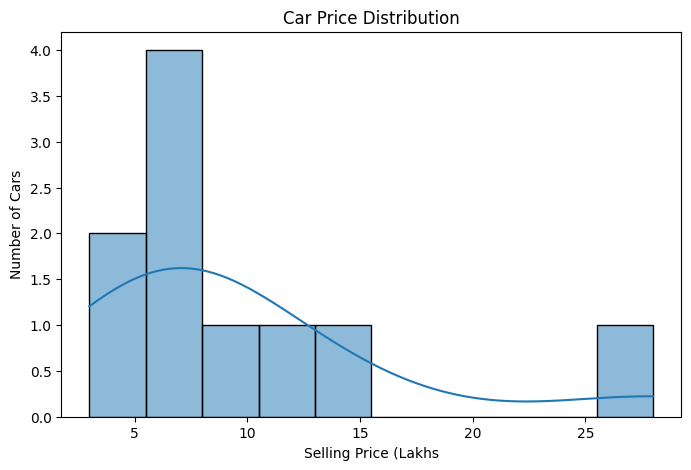

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(pdf['price'], bins=10, kde=True)
plt.title("Car Price Distribution")
plt.xlabel("Selling Price (Lakhs")
plt.ylabel("Number of Cars")


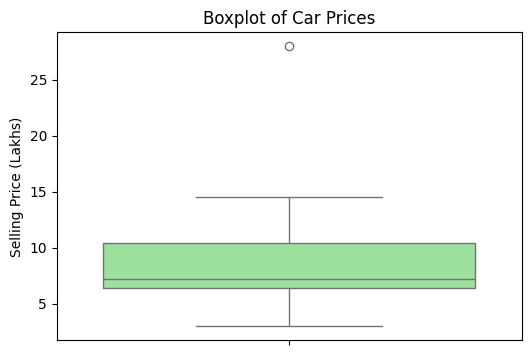

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(y=pdf['price'], color='lightgreen')
plt.title("Boxplot of Car Prices")
plt.ylabel("Selling Price (Lakhs)")
plt.show()
